In [1]:
# Random Forest Model
# This notebook explains the Random Forest model used for import shipment risk analysis.
# The model is trained without `tax` and `tax_ratio` in order to avoid tax-related target leakage.

In [2]:
from pathlib import Path
import json

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
TRAINING_SAMPLE_SIZE = 60000


def find_ml_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for candidate in candidates:
        direct_dataset = candidate / "data" / "processed" / "cleaned_dataset.csv"
        nested_dataset = candidate / "ml" / "data" / "processed" / "cleaned_dataset.csv"

        if direct_dataset.exists():
            return candidate

        if nested_dataset.exists():
            return candidate / "ml"

    raise FileNotFoundError("Could not find ml/data/processed/cleaned_dataset.csv")


ML_DIR = find_ml_dir()
DATA_PATH = ML_DIR / "data" / "processed" / "cleaned_dataset.csv"
MODELS_DIR = ML_DIR / "models"

MODEL_PATH = MODELS_DIR / "import_risk_random_forest.joblib"
METRICS_PATH = MODELS_DIR / "random_forest_metrics.json"
REPORT_PATH = MODELS_DIR / "random_forest_report.txt"

print("ML directory:", ML_DIR)
print("Dataset path:", DATA_PATH)

ML directory: C:\Users\admin\Desktop\import-risk-analysis-system\ml
Dataset path: C:\Users\admin\Desktop\import-risk-analysis-system\ml\data\processed\cleaned_dataset.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (263821, 17)


,product_name,price_usd,weight_kg,length_m,width_m,height_m,shipment_date,destination_port,volume_m3,max_dimension_m,dimension_sum_m,density_kg_m3,value_per_kg,value_per_m3,tax,tax_ratio,risk
0,Camera Bag,37.66,1.10,0.40,0.39,0.26,2023-03-19,Port of Singapore (Singapore),0.0406,0.40,1.05,27.1203,34.2364,927.5862,6.26,0.1662,LOW RISK
1,Portable Bluetooth Keyboard,144.65,0.39,0.11,0.06,0.03,2023-03-21,Port of Busan (South Korea),0.0002,0.11,0.20,1969.6970,370.8974,723250.0000,16.76,0.1159,LOW RISK
2,Large Flat Rate Box,38.57,0.97,0.79,0.55,0.35,2023-03-25,Port of Tianjin (China),0.1521,0.79,1.69,6.3784,39.7629,253.5832,6.90,0.1789,LOW RISK
3,Ceramic Tiles,10.34,6.22,0.36,0.37,0.02,2023-03-15,Port of Shanghai (China),0.0027,0.37,0.75,2334.8348,1.6624,3829.6296,1.60,0.1547,LOW RISK
4,Garden Hose,21.63,1.18,17.77,0.27,0.13,2023-03-25,Port of Tianjin (China),0.6237,17.77,18.17,1.8919,18.3305,34.6801,1.39,0.0643,HIGH RISK


In [4]:
risk_distribution = (
    df["risk"]
    .value_counts()
    .rename_axis("risk")
    .reset_index(name="count")
)

risk_distribution["percentage"] = (
    risk_distribution["count"] / risk_distribution["count"].sum() * 100
).round(2)

display(risk_distribution)

,risk,count,percentage
0,LOW RISK,224414,85.06
1,HIGH RISK,39407,14.94


In [5]:
FEATURE_COLUMNS = [
    "price_usd",
    "weight_kg",
    "length_m",
    "width_m",
    "height_m",
    "volume_m3",
    "max_dimension_m",
    "dimension_sum_m",
    "density_kg_m3",
    "value_per_kg",
    "value_per_m3",
]

REMOVED_FEATURES = ["tax", "tax_ratio"]

print("Features used:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

print("\nRemoved leakage-risk features:")
for feature in REMOVED_FEATURES:
    print("-", feature)

Features used:
- price_usd
- weight_kg
- length_m
- width_m
- height_m
- volume_m3
- max_dimension_m
- dimension_sum_m
- density_kg_m3
- value_per_kg
- value_per_m3

Removed leakage-risk features:
- tax
- tax_ratio


In [6]:
required_columns = set(FEATURE_COLUMNS + ["risk"])
missing_columns = sorted(required_columns.difference(df.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


In [7]:
def limit_dataset_size(df, max_rows):
    if len(df) <= max_rows:
        return df.reset_index(drop=True)

    sampled_df, _ = train_test_split(
        df,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=df["risk"],
    )

    return sampled_df.reset_index(drop=True)


df_model = limit_dataset_size(df, TRAINING_SAMPLE_SIZE)

print(f"Rows used for Random Forest training: {len(df_model):,}")
display(df_model["risk"].value_counts())

Rows used for Random Forest training: 60,000


risk
LOW RISK     51038
HIGH RISK     8962
Name: count, dtype: int64

In [8]:
X = df_model[FEATURE_COLUMNS].copy()
y = df_model["risk"].map({
    "LOW RISK": 0,
    "HIGH RISK": 1,
})

if y.isna().any():
    raise ValueError("Risk column contains invalid values.")

print("X shape:", X.shape)
print("y distribution:")
display(y.value_counts().rename(index={0: "LOW RISK", 1: "HIGH RISK"}))

X shape: (60000, 11)
y distribution:


risk
LOW RISK     51038
HIGH RISK     8962
Name: count, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 48000
Testing rows: 12000


In [10]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline accuracy:", round(baseline_accuracy, 4))

Baseline accuracy: 0.8507


In [11]:
random_forest_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest without tax and tax_ratio...")
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest without tax and tax_ratio...
Random Forest training completed.


In [12]:
random_forest_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest without tax and tax_ratio...")
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest without tax and tax_ratio...
Random Forest training completed.


In [14]:
y_pred = random_forest_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("Confusion Matrix:")
print(matrix)

Accuracy: 0.7956
Baseline Accuracy: 0.8507
Precision: 0.1539
Recall: 0.082
F1 Score: 0.107
Confusion Matrix:
[[9400  808]
 [1645  147]]


In [15]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["LOW RISK", "HIGH RISK"],
)

print(report)

              precision    recall  f1-score   support

    LOW RISK       0.85      0.92      0.88     10208
   HIGH RISK       0.15      0.08      0.11      1792

    accuracy                           0.80     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.75      0.80      0.77     12000



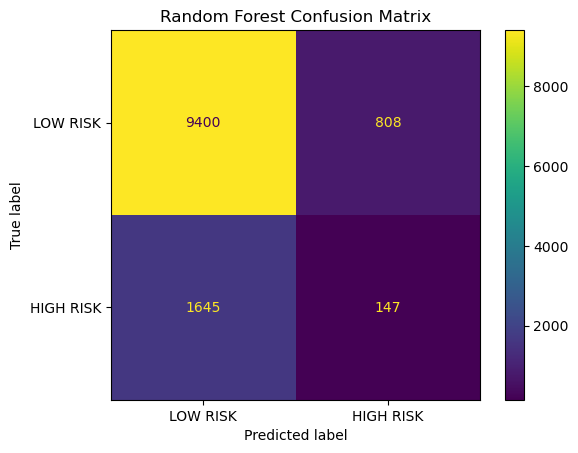

In [16]:
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["LOW RISK", "HIGH RISK"],
)

display_matrix.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": random_forest_model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False,
).reset_index(drop=True)

feature_importance["importance"] = feature_importance["importance"].round(6)

display(feature_importance)

,feature,importance
0,value_per_kg,0.113592
1,value_per_m3,0.109919
2,price_usd,0.106887
3,density_kg_m3,0.105807
4,weight_kg,0.098110
5,volume_m3,0.091494
6,dimension_sum_m,0.078080
7,width_m,0.077101
8,length_m,0.075199
9,height_m,0.072098


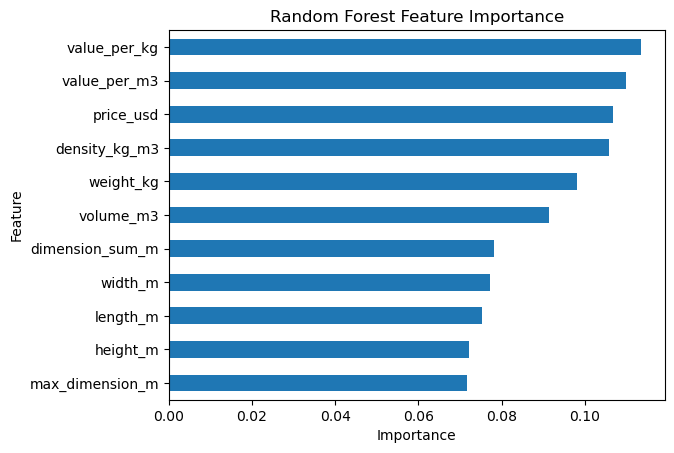

In [18]:
feature_importance.sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

metrics = {
    "accuracy": round(float(accuracy), 4),
    "precision": round(float(precision), 4),
    "recall": round(float(recall), 4),
    "f1_score": round(float(f1), 4),
    "confusion_matrix": matrix.tolist(),
    "classification_report": report,
    "baseline_accuracy": round(float(baseline_accuracy), 4),
    "feature_importance": feature_importance.to_dict(orient="records"),
    "features_used": FEATURE_COLUMNS,
    "rows_used": len(X),
    "test_rows": len(X_test),
    "model": "Random Forest",
}

joblib.dump(random_forest_model, MODEL_PATH)

with METRICS_PATH.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics, metrics_file, indent=2)

with REPORT_PATH.open("w", encoding="utf-8") as report_file:
    report_file.write("Random Forest Evaluation\n")
    report_file.write(f"Features: {', '.join(FEATURE_COLUMNS)}\n\n")
    report_file.write(f"Accuracy: {metrics['accuracy']}\n")
    report_file.write(f"Baseline Accuracy: {metrics['baseline_accuracy']}\n")
    report_file.write(f"Precision: {metrics['precision']}\n")
    report_file.write(f"Recall: {metrics['recall']}\n")
    report_file.write(f"F1 Score: {metrics['f1_score']}\n")
    report_file.write(f"Rows Used: {metrics['rows_used']}\n")
    report_file.write(f"Test Rows: {metrics['test_rows']}\n")
    report_file.write(f"Confusion Matrix: {metrics['confusion_matrix']}\n\n")

    report_file.write("Feature Importance:\n")
    for item in metrics["feature_importance"]:
        report_file.write(f"- {item['feature']}: {item['importance']}\n")

    report_file.write("\nClassification Report:\n")
    report_file.write(metrics["classification_report"])

print("Saved model:", MODEL_PATH)
print("Saved metrics:", METRICS_PATH)
print("Saved report:", REPORT_PATH)

Saved model: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\import_risk_random_forest.joblib
Saved metrics: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\random_forest_metrics.json
Saved report: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\random_forest_report.txt
